# Bogotá, two ways

A **Local Climate Zone** is a way of describing the surface around a place — how much of the
ground is building, how tall, how dense, how green — using seventeen classes: ten built types
numbered 1 to 10 and seven natural land-cover types lettered A to G. Stewart & Oke introduced the
scheme in 2012 so that temperature measurements taken in different cities could be compared by
the kind of surface they were taken over, rather than by the word "urban". Throughout this
notebook the abbreviation is **LCZ**.

This notebook runs `lczkit` end to end over a 25 km² window of Bogotá, twice — once on a
**100 m grid** and once on **organic patch units**, larger polygons grown from city blocks — and
embeds the interactive map each run produced.

Bogotá is here for a measurable reason. `lczkit` takes its buildings from **Overture Maps**, an
open dataset that merges OpenStreetMap, Esri, Google and Microsoft sources — and does so
*winner-takes-all per building*, so a footprint's attributes come from whichever source won its
geometry and are never blended. Only OpenStreetMap among those carries building heights. Across
Bogotá's full 1 169 km² extent that leaves **0.50%** of building heights coming from Overture. A
90 m radar mosaic derived from the German TanDEM-X satellites answers for 97.8% of the rest, and
Berlin's equivalent Overture figure is about 80%.

That gap is the constraint this package exists to report, and Bogotá is close to the worst case
for it — so the **height-provenance layer**, not the LCZ layer, is the thing to look at first in
both maps below.

**What this is not.** It is a demonstration over one window, not a validated map of Bogotá. The
window is 25 km² against the city's 1 169; the reference at the end is a handful of hand-drawn
polygons from two submissions; and no ceiling is computed, because Bogotá does not carry the
labelled data that would make one meaningful. Every one of those limits is stated again where
it bites.

In [1]:
# Before the imports, deliberately: something in the chain below imports `tqdm.auto`, which warns
# at import time that `ipywidgets` is missing. That warning would otherwise be the first thing on
# this page, and it is about a progress bar nothing here draws.
import warnings

# `TqdmWarning` subclasses `Warning` and not `UserWarning`, so it needs naming by message.
warnings.filterwarnings("ignore", message="IProgress not found")
warnings.filterwarnings("ignore", category=UserWarning)

import json
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from lczkit.cities import densest_window
from lczkit.config import Settings
from lczkit.pipeline import run_pipeline
from lczkit.presets import apply_preset
from lczkit.units.grid import GridUnits
from lczkit.validation.agreement import agreement
from lczkit.validation.wudapt import load_wudapt, read_wudapt, wudapt_lcz

pd.set_option("display.width", 110)
plt.rcParams.update({"figure.dpi": 120, "font.size": 9, "axes.grid": True, "grid.alpha": 0.3})

## The extent, and why Bogotá cannot be validated here

`lczkit run --city bogota` works. It resolves against the **Global Urban Polygons and Points
Dataset (GUPPD)**, a gazetteer of 5 558 urban regions from NASA's Socioeconomic Data and
Applications Center and the European Commission's Joint Research Centre; Bogotá is one of them,
identified by `SMOD_ID 30_3370`. That identifier is used rather than the name because 149 of the
5 558 names are shared by more than one region.

What Bogotá is *not* is one of the 28 cities in `lczkit.cities`, which is a different list for a
different purpose: every city in it is there because **So2Sat LCZ42** — a set of hand-drawn LCZ
labels produced for a machine-learning benchmark, covering 51 cities in 320 m patches — covers it
densely enough to validate against. The screen is 500 labelled patches across at least 4 classes.
**Bogotá carries 8 patches, all of them LCZ 7** — eight against five hundred, one class against
four. So the `--so2sat-window` option has nothing to offer here, and no ceiling can be computed
for this window.

The extent is quoted literally below rather than looked up, so this notebook reproduces from
itself — without a `DATA_DIR`, and without depending on which release of the bounds table is on a
given machine. It is the same window the full-city run on disk used.

In [2]:
BOGOTA_GUPPD = (-74.281808, 4.474229, -74.010769, 4.822439)  # NASA GUPPD SMOD_ID 30_3370
WUDAPT_FILE = "LCZ-Generator_training_areas_2024-10-01.gpkg"
WUDAPT_LAYER = "LCZ-Generator_training_areas_2024-10-01"
WINDOW_KM = 5.0

settings = apply_preset(Settings.load(run_id="docs-bogota-grid"))
settings.validation.wudapt.filename = WUDAPT_FILE
settings.validation.wudapt.layer = WUDAPT_LAYER
wudapt_path = settings.source_dir(settings.validation.wudapt.source_dir_name) / WUDAPT_FILE

print("Overture release pinned by the preset:", settings.overture.release)
print("GUPPD extent:", BOGOTA_GUPPD)

Overture release pinned by the preset: 2026-07-22.0
GUPPD extent: (-74.281808, 4.474229, -74.010769, 4.822439)


## Choosing the window

A demonstration window has to be small enough to run in one sitting and to ship inside a
documentation site, and it should contain something to compare against. `densest_window` is the
helper the multi-city comparison uses to place a square on the thickest part of a reference;
pointing it at Bogotá's **WUDAPT** polygons puts the window where the evidence is rather than in
the middle of the bounding box.

WUDAPT — the World Urban Database and Access Portal Tools — is a community effort to describe
cities by LCZ. Its training areas are polygons drawn by contributors worldwide: far wider coverage
than So2Sat, and irregular, overlapping and of uneven vintage.

In [3]:
wudapt_city = read_wudapt(wudapt_path, BOGOTA_GUPPD, layer=WUDAPT_LAYER)
window = densest_window(wudapt_city.to_crs(4326), side_km=WINDOW_KM)

print(f"WUDAPT polygons over the whole GUPPD extent: {len(wudapt_city)}")
print(f"  classes present: {sorted(wudapt_city['class'].astype(int).unique().tolist())}")
print(f"  distinct submissions: {wudapt_city['submission_id'].nunique()}")
print(f"\n{WINDOW_KM:.0f} km window: {tuple(round(v, 6) for v in window)}")
print(f"  100 m cells it will contain: {len(GridUnits().generate(window)):,}")

WUDAPT polygons over the whole GUPPD extent: 80
  classes present: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]
  distinct submissions: 2

5 km window: (-74.110729, 4.583277, -74.065538, 4.628322)


  100 m cells it will contain: 2,601


## The first run — a 100 m grid

The grid is the default. It is what published LCZ maps, the reference label sets, and the
workflows that feed LCZ maps into the Weather Research and Forecasting model all use.

`run_pipeline` runs nine stages: clean the Overture vectors, fill building heights through the
cascade of sources, build the spatial units, read land cover, record where each height came from,
measure the urban canopy parameters — the numbers describing the shape of the surface — classify,
write the run, and build the map site.

The configuration comes from `apply_preset` and is never restated here. Several settings default
to nothing and raise if used, deliberately, so that an invented value cannot travel into a run's
record looking like a measurement; the preset is what fills them with the values every published
figure was produced under.

In [4]:
settings.units.strategy = "grid"
settings.units.cell_size_m = 100.0

grid_result = run_pipeline(settings, window, build_site_after=True)
grid_dir = grid_result.run_dir
print(f"grid run -> {grid_dir}  ({grid_result.seconds / 60:.1f} min)")

/home/acz25/repos/lczkit/src/lczkit/cleaning/streets.py:381: UserWarning: No threshold found. Either your dataset it too small or the distribution of the face artifact index does not follow the expected shape.
  faces = neatnet.FaceArtifacts(_preprocess(streets)).polygons
/home/acz25/repos/lczkit/src/lczkit/cleaning/streets.py:381: UserWarning: No threshold found. Either your dataset it too small or the distribution of the face artifact index does not follow the expected shape.
  faces = neatnet.FaceArtifacts(_preprocess(streets)).polygons


grid run -> /maps/acz25/phd-thesis-data/output/lczkit/docs-bogota-grid  (2.8 min)


`No threshold found` above is expected at this size and is not an error. Street simplification
runs tile by tile, and a tile whose street network is too sparse cannot supply the distribution
the simplification threshold is read from. The threshold is **pooled across tiles** rather than
taken from any one of them, which is what makes a whole-city run finish in minutes rather than
hours, so tiles that abstain cost nothing as long as some do not. A window small
enough that *every* tile abstains would fall back to a default, and that is a reason not to
shrink this one further.

In [5]:
stages = pd.Series(grid_result.stages, name="seconds").rename_axis("stage").round(1)
stages.to_frame().assign(share=lambda d: (d.seconds / d.seconds.sum()).map("{:.1%}".format))

,seconds,share
stage,,
clean_vectors,125.2,73.5%
heights,20.1,11.8%
units,0.2,0.1%
land_cover,1.1,0.6%
provenance,3.0,1.8%
parameters,16.1,9.4%
classify,0.0,0.0%
write_run,2.1,1.2%
build_site,2.6,1.5%


## Where the heights came from

This is the table the package is built to produce. `height_frac_*` is the share of a unit's
**building area** whose height came from each tier, and it is reported per unit precisely so a
reader can tell "90% measured heights" from "90% coarse raster fallback" — the two produce the
same LCZ label with very different trustworthiness.

In [6]:
grid_manifest = json.loads((grid_dir / "manifest.json").read_text())
# The whole-city run, if it is on this machine. It is quoted, never re-run: 1 169 km² and
# 2.35 million buildings is an hour of CPU and is not what this notebook is for.
full_city = grid_dir.parent / "bogota" / "manifest.json"


def tier_shares(manifest: dict) -> pd.Series:
    """Share of buildings resolved by each cascade tier, plus what stayed unresolved."""
    fill = manifest["height_fill"]
    counts: dict[str, int] = {}
    for tier in fill["tiers"]:
        for source, n in tier["filled_by_source"].items():
            counts[source] = counts.get(source, 0) + n
    counts["unresolved"] = fill["n_unresolved"]
    return pd.Series(counts) / fill["n_buildings"]


shares = tier_shares(grid_manifest).to_frame("this window")
if full_city.is_file():
    shares["whole city"] = tier_shares(json.loads(full_city.read_text()))
    shares = shares.fillna(0.0)
shares.map("{:.2%}".format)

,this window,whole city
overture_num_floors,0.50%,0.41%
overture_height,0.03%,0.09%
wsf3d,99.33%,97.82%
ghsl,0.14%,1.29%
unresolved,0.00%,0.40%


Overture's height coverage is not low here because Bogotá is poorly mapped. It is low because
Overture's conflation is **winner-takes-all per footprint**: a building's attributes come from
whichever source won its geometry, and they are never fused across sources. Read the table
below by row — the source holding 90% of this window's footprints carries a height for none of
them, and OpenStreetMap, which does carry some, won 7% of the ground:

In [7]:
availability = pd.DataFrame(grid_manifest["height_source_availability"]["by_footprint_dataset"])
availability.assign(
    height_rate=lambda d: (d.n_with_height / d.n_buildings).map("{:.2%}".format),
    floors_rate=lambda d: (d.n_with_num_floors / d.n_buildings).map("{:.2%}".format),
).sort_values("n_buildings", ascending=False)

,dataset,n_buildings,n_with_height,n_with_num_floors,height_rate,floors_rate
0,Esri Community Maps,103821,0,0,0.00%,0.00%
1,OpenStreetMap,7970,32,600,0.40%,7.53%
2,Google Open Buildings,2699,0,0,0.00%,0.00%
3,Microsoft ML Buildings,455,0,0,0.00%,0.00%


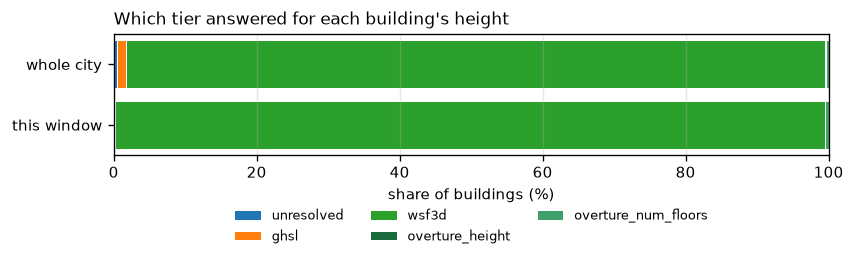

In [8]:
fig, ax = plt.subplots(figsize=(7.2, 2.6))
plot = shares.iloc[::-1] * 100
left = np.zeros(len(plot.columns))
palette = {"overture_height": "#1a6b3c", "overture_num_floors": "#3fa06a"}
for source, row in plot.iterrows():
    ax.barh(
        plot.columns,
        row.to_numpy(),
        left=left,
        label=source,
        color=palette.get(source, None),
        edgecolor="white",
        linewidth=0.6,
    )
    left = left + row.to_numpy()
ax.set_xlim(0, 100)
ax.set_xlabel("share of buildings (%)")
ax.set_title("Which tier answered for each building's height", loc="left", fontsize=10)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.35), ncol=3, frameon=False, fontsize=8)
ax.grid(axis="y", visible=False)
fig.tight_layout()
plt.show()

## The second run — organic patch units

A 100 m cell is not the object Stewart & Oke's parameter ranges describe, and it is not the object
the reference label sets describe either: a So2Sat patch is 10.24 ha and a WUDAPT polygon runs
2.2–52 ha, against the cell's 1.00 ha.

`PatchUnits` builds larger units in two steps. First it cuts the area into **enclosures** — the
faces left when the street network, railways and water are treated as barriers, which is to say
city blocks. Footpaths are left out of that barrier set, because including them makes the result
mostly a measure of how thoroughly a city's paths have been surveyed. Then it merges each block
into the contiguous neighbour it most resembles, until it reaches an area floor.

`patch_min_area_m2` is a **floor, not a target**. Merging stops when a unit reaches it, and the
merge that got it there overshoots, so the resulting median lands at roughly twice the value —
5 ha gives a median near 10 ha, which is where the reference patches are.

In [9]:
patch_settings = apply_preset(Settings.load(run_id="docs-bogota-patch"))
patch_settings.validation.wudapt.filename = WUDAPT_FILE
patch_settings.validation.wudapt.layer = WUDAPT_LAYER
patch_settings.units.strategy = "patch"
patch_settings.units.patch_min_area_m2 = 50_000.0  # 5 ha
patch_settings.units.patch_max_area_m2 = 500_000.0  # 50 ha
patch_settings.units.drop_pedestrian_barriers = True

patch_result = run_pipeline(patch_settings, window, build_site_after=True)
patch_dir = patch_result.run_dir
print(f"patch run -> {patch_dir}  ({patch_result.seconds / 60:.1f} min)")

/home/acz25/repos/lczkit/src/lczkit/cleaning/streets.py:381: UserWarning: No threshold found. Either your dataset it too small or the distribution of the face artifact index does not follow the expected shape.
  faces = neatnet.FaceArtifacts(_preprocess(streets)).polygons
/home/acz25/repos/lczkit/src/lczkit/cleaning/streets.py:381: UserWarning: No threshold found. Either your dataset it too small or the distribution of the face artifact index does not follow the expected shape.
  faces = neatnet.FaceArtifacts(_preprocess(streets)).polygons


patch run -> /maps/acz25/phd-thesis-data/output/lczkit/docs-bogota-patch  (2.6 min)


In [10]:
patch_manifest = json.loads((patch_dir / "manifest.json").read_text())
report = patch_manifest["units"]
pd.Series(
    {
        "seeds (enclosures)": f"{report['n_seeds']:,}",
        "patches after merging": f"{report['n_patches']:,}",
        "merges performed": f"{report['n_merges']:,}",
        "isolates (unmergeable)": report["n_isolates"],
        "left below the floor": report["n_below_minimum"],
        "blocked by the ceiling": report["n_blocked_by_max_area"],
        "seed area p50 (ha)": round(report["seed_area_quantiles"]["p50"] / 10_000, 2),
        "patch area p50 (ha)": round(report["patch_area_quantiles"]["p50"] / 10_000, 2),
    },
    name="patch merge",
).to_frame()

,patch merge
seeds (enclosures),"2,882"
patches after merging,251
merges performed,"2,631"
isolates (unmergeable),0
left below the floor,0
blocked by the ceiling,0
seed area p50 (ha),0.58
patch area p50 (ha),8.61


### Unit scale, against the objects the references describe

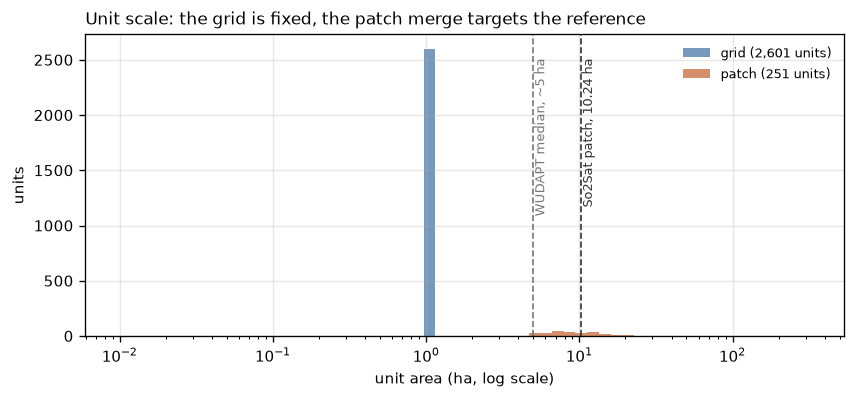

grid  median   1.00 ha   p10   1.00   p90   1.00
patch median   8.61 ha   p10   5.41   p90  15.67


In [11]:
grid_units = gpd.read_parquet(grid_dir / "units.parquet", columns=["geometry"])
patch_units = gpd.read_parquet(patch_dir / "units.parquet", columns=["geometry"])
grid_ha = grid_units.geometry.area / 10_000
patch_ha = patch_units.geometry.area / 10_000

fig, ax = plt.subplots(figsize=(7.2, 3.4))
bins = np.logspace(-2, 2.5, 60)
ax.hist(grid_ha, bins=bins, alpha=0.75, label=f"grid ({len(grid_ha):,} units)", color="#4878a8")
ax.hist(patch_ha, bins=bins, alpha=0.75, label=f"patch ({len(patch_ha):,} units)", color="#c86a3a")
for x, text, colour in [
    (10.24, "So2Sat patch, 10.24 ha", "#333333"),
    (5.0, "WUDAPT median, ~5 ha", "#777777"),
]:
    ax.axvline(x, color=colour, linestyle="--", linewidth=1)
    ax.text(
        x, ax.get_ylim()[1] * 0.92, f" {text}", fontsize=7.5, color=colour, rotation=90, va="top"
    )
ax.set_xscale("log")
ax.set_xlabel("unit area (ha, log scale)")
ax.set_ylabel("units")
ax.set_title(
    "Unit scale: the grid is fixed, the patch merge targets the reference", loc="left", fontsize=10
)
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
plt.show()

for name, areas in (("grid ", grid_ha), ("patch", patch_ha)):
    p10, p50, p90 = areas.quantile([0.1, 0.5, 0.9])
    print(f"{name} median {p50:6.2f} ha   p10 {p10:6.2f}   p90 {p90:6.2f}")

## What the two runs classified

In [12]:
legend = {int(k): v for k, v in grid_manifest["legend"].items()}
summary = (
    pd.DataFrame(
        {
            "grid": pd.Series(
                {int(k): v for k, v in grid_manifest["classification_summary"]["labels"].items()}
            ),
            "patch": pd.Series(
                {int(k): v for k, v in patch_manifest["classification_summary"]["labels"].items()}
            ),
        }
    )
    .fillna(0)
    .astype(int)
)
summary.insert(0, "class", [legend[c]["name"] for c in summary.index])
summary.assign(
    grid_share=lambda d: (d.grid / d.grid.sum()).map("{:.1%}".format),
    patch_share=lambda d: (d.patch / d.patch.sum()).map("{:.1%}".format),
).rename_axis("code")

,class,grid,patch,grid_share,patch_share
code,,,,,
1,Compact high-rise,59,8,2.3%,3.2%
2,Compact midrise,178,16,6.8%,6.4%
3,Compact low-rise,495,53,19.0%,21.1%
4,Open high-rise,43,3,1.7%,1.2%
5,Open midrise,122,12,4.7%,4.8%
6,Open low-rise,417,40,16.0%,15.9%
7,Lightweight low-rise,19,0,0.7%,0.0%
8,Large low-rise,948,100,36.4%,39.8%
9,Sparsely built,148,11,5.7%,4.4%


## Agreement against WUDAPT — with the caveat that carries it

`run_pipeline` never runs validation, deliberately: wiring it into the chain would make every run
depend on a reference dataset being present. Validation is a separate call, and this is it.

Two scores appear below. **Overall accuracy (`OA`)** counts a unit right only if its class matches
the reference exactly. **Weighted overall accuracy (`OA_w`)** gives partial credit according to
how similar the two classes are — the next cell explains why the gap between them is the
interesting part.

**Read the numbers as a demonstration of the instrument, not as a result.** Bogotá's WUDAPT
coverage inside this window is a handful of polygons from two submissions. A per-class figure
computed on single-digit counts is noise, and no ceiling accompanies these numbers because Bogotá
has no independent labelled set to compute one against — its 8 So2Sat patches are all one class.
Everywhere this project reports a real agreement figure it reports the ceiling beside it; here
there is nothing honest to put there.

In [13]:
def score(run_dir: Path, config_settings: Settings) -> tuple[pd.Series, object]:
    """Agreement for one run against the WUDAPT polygons covering its window."""
    units = gpd.read_parquet(run_dir / "units.parquet", columns=["geometry", "lcz_primary"])
    polygons, selection = load_wudapt(
        wudapt_path, window, crs=units.crs, config=config_settings.validation.wudapt
    )
    labels, match = wudapt_lcz(units, polygons)
    result = agreement(
        units["lcz_primary"],
        labels["reference_lcz"],
        units.geometry.area,
        coverage=labels["reference_coverage"],
        config=config_settings.validation,
        reference_file=wudapt_path.name,
    )
    return (
        pd.Series(
            {
                "units": result.n_units,
                "compared": result.n_compared,
                "overall": f"{result.overall_agreement:.1%}",
                "built": f"{result.built_agreement:.1%}",
                "natural": f"{result.natural_agreement:.1%}",
                "natural share": f"{result.natural_share:.1%}",
                "OA_w (Bechtel 2020)": f"{result.weighted_agreement:.1%}",
            }
        ),
        selection,
    )


grid_score, selection = score(grid_dir, settings)
patch_score, _ = score(patch_dir, patch_settings)

print(f"WUDAPT polygons in the window: {selection.n_kept} kept of {selection.n_read} read")
print(f"  licences: {', '.join(selection.licences)}")
pd.DataFrame({"grid": grid_score, "patch": patch_score})

WUDAPT polygons in the window: 17 kept of 17 read
  licences: CC BY-NC-SA 4.0


,grid,patch
units,2601,251
compared,187,17
overall,16.0%,22.5%
built,16.0%,22.5%
natural,0.0%,0.0%
natural share,0.0%,0.0%
OA_w (Bechtel 2020),81.1%,85.5%


**`OA_w` is not a better score, and the gap between the two columns is the reading.** Plain `OA`
counts a cell right only if the class matches exactly. `OA_w` weights each confusion by how
similar the two classes are, using Bechtel, Demuzere & Stewart's (2020) matrix — so a compact
midrise called open midrise scores most of a point, and only a built type called water scores
near zero. An `OA_w` far above `OA` therefore says the map is landing in *neighbouring* classes
rather than at random, which is a real and useful thing to know and is **not** an accuracy of
80-something per cent. It is reported beside `OA` and never instead of it, here and everywhere
else in this package.

Note the licence line the run printed. WUDAPT's polygons are CC BY-SA and CC BY-NC-SA 4.0 **per
polygon**, and the ones covering this window are the non-commercial variety. That constrains the
reference data, not this MIT-licensed package — and a run states it from the polygons it actually
read rather than from a constant, which is why it is printed here rather than asserted.

## The maps

Each run wrote a self-contained web map. It is drawn by MapLibre GL, a browser mapping library,
reading **PMTiles** — a single-file tile archive served over ordinary web requests, so no tile
server is involved. Nothing is fetched from a content delivery network and no interactive-map
account key is needed. The two below are those maps, copied into this documentation unchanged.

**Open the layer selector and choose a height-provenance layer.** On the LCZ layer the two runs
look like ordinary maps; on `WSF-3D, 90 m raster` they show that almost every building's height in
this city came from a 90 m radar mosaic, which is the finding. Click any unit for its full
parameter table, its distance to all 17 classes, and where its height came from.

> **If these frames are blank, you are previewing locally.** PMTiles asks a server for byte ranges
> of a file, and `pmtiles.js` raises rather than guessing when a server answers such a request
> with the whole file instead. GitHub Pages honours ranges — measured, `206 Partial Content` with
> `Accept-Ranges: bytes` — so the published page is fine. **`mkdocs serve` does not**, so the maps
> are blank under it. Build the site and serve it with the range-capable server this package
> already ships for exactly this reason:
>
> `mkdocs build` &nbsp;then&nbsp; `python -c "from lczkit.viz import serve; serve('site')"`

### The 100 m grid

<iframe src="../bogota-grid/index.html" title="Bogotá on the 100 m grid" width="100%" height="620"
        loading="lazy" style="border:1px solid rgba(128,128,128,0.35);border-radius:4px"></iframe>

### Organic patch units

<iframe src="../bogota-patch/index.html" title="Bogotá on patch units" width="100%" height="620"
        loading="lazy" style="border:1px solid rgba(128,128,128,0.35);border-radius:4px"></iframe>

## What to take from this, and what not to

**The height cascade is doing nearly all the work, and the map says so.** That is the design bet:
a run that fills 97.8% of its heights from a 90 m raster and a run that measures them are not the
same product, and only one of them can tell low-rise from mid-rise from high-rise inside a mixed
unit. The provenance layers exist so that difference is visible rather than inferred.

**The two runs are not comparable as accuracy.** No claim that one is better is made here. The
package's sixteen-city comparison found block-based units ahead on the built classes and behind
overall, split along the same regional line, three times — which is why the unit strategy is
configuration with the grid as the default and no automatic selection. One window of one city
adds nothing to that.

**Patch units are built using parameters the classifier then scores.** The merge compares
neighbours on building surface fraction and height, two of the seven quantities the classification
scores. That is the standard shape of this kind of region-building and it cannot inflate agreement
with an external reference, but it does make any within-run parameter statistic weaker on patches
than on cells.

Where to go next: the [API reference](../../api/) for every public symbol, and the
[glossary](../../glossary/) for any term used here.

<!-- Those links are built-site URLs, not `../api/index.md`: nbconvert renders this cell to HTML
     before mkdocs sees it, so a `.md` target is never rewritten and would ship as a 404. -->